0) Aplicar descenso del gradiente óptimo a la función :

$$f(x,y)=x^2+2y^2−2xy−2y$$ 

In [1]:
from sympy import *
import matplotlib.pyplot as plt
import numpy as np

In [2]:
x, y, t = symbols('x y t')

In [21]:
38 * t

38*t

In [49]:
def learnin_rate_decay(punto, ecuacion):
    decuacion_x , decuacion_y = diff(ecuacion,x), diff(ecuacion,y)

    punto_t =[t * decuacion_x.subs([(x,punto[0]),(y,punto[1])]), t * decuacion_y.subs([(x,punto[0]),(y,punto[1])])]

    ecuacion_t = ecuacion.subs([(x,punto_t[0]),(y,punto_t[1])])

    return round(min(solve((ecuacion_t), t)), 5) if min(solve((ecuacion_t), t)) > 0 else round(max(solve((ecuacion_t), t)), 5)

In [50]:
def grad(ecuacion, inicial, maxit, tol):

    alfa, punto_x, punto_y  = [[] for val in range(3)]

    decuacion_x , decuacion_y = diff(ecuacion,x), diff(ecuacion,y)

    critico_vector = list(solve((decuacion_x , decuacion_y), x, y).values())


    i = 0
    while ( abs(inicial[0] - critico_vector[0]) > tol or abs(inicial[1] - critico_vector[1]) > tol ) and i < maxit:
        
        alfa_grad = learnin_rate_decay(inicial,ecuacion)

        alfa.append(alfa_grad)

        inicial[0] = inicial[0] - alfa_grad * decuacion_x.subs([(x,inicial[0]),(y,inicial[1])]) 
        inicial[1] = inicial[1] - alfa_grad * decuacion_y.subs([(x,inicial[0]),(y,inicial[1])])

        punto_x.append(inicial[0])
        punto_y.append(inicial[1])
        i += 1


    return inicial, alfa, [punto_x, punto_y]

In [52]:
descenso_graciente = grad(x**2 +2*y**2 -2*x*y -2*y, [20,20], 100, 0.1)

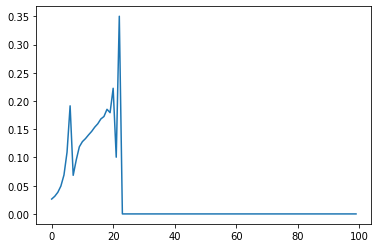

In [53]:
plt.plot(descenso_graciente[1])

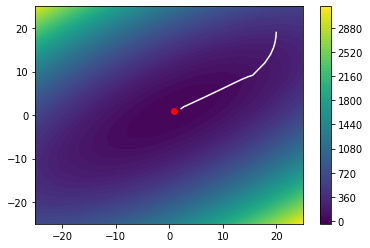

In [54]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100 
rango=25
 
X=np.linspace(-rango,rango,resolucion) 
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
f  = lambda X: X[0]**2 + 2*X[1]**2 - 2*X[0]*X[1] - 2*X[1]
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar() ## barra vertical al lado del dibujo en los ejes de coordenadas
plt.plot(1,1,"o",c="red")

plt.plot(descenso_graciente[2][0],descenso_graciente[2][1],c="white")

plt.show()

1) (Dos puntos adicionales) Optimizar la función mediante Descenso del Gradiente: estimar el gradiente o calcularlo analíticamente
$$f(x)=sin(1/2∗x^2−1/4∗y^2+3)∗cos(2∗x+1−e^y)$$

In [3]:
import math

In [4]:
ecuacion = sin((1/2)*x**2 - (1/4) * y **2 + 3) * cos(2*x + 1 - math.e ** y)

In [5]:
ecuacion

sin(0.5*x**2 - 0.25*y**2 + 3)*cos(-2.71828182845905**y + 2*x + 1)

## Gradiente de x

In [6]:
dif_x = diff(ecuacion,x)
dif_x
solve((dif_x), x, y)

NotImplementedError: No algorithms are implemented to solve equation x*cos(-(54365636569181/20000000000000)**y + 2*x + 1)*cos(x**2/2 - y**2/4 + 3) - 2*sin(-(54365636569181/20000000000000)**y + 2*x + 1)*sin(x**2/2 - y**2/4 + 3)

Se podría simplificar esta expresión a:

$$ \frac{\partial}{\partial x} = x \cdot cos(a) \cdot cos(b) - 2 \cdot sin(a) \cdot sin(b) $$

como:

$$cos(a) \cdot cos(b) = \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) $$
$$sin(a) \cdot sin(b) = \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$

sustituyendo:

$$ x \cdot \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) - 2 \cdot \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$
$$ \frac{x}{2} \cdot (cos(a+b) + cos(a-b)) - cos(a-b) + cos(a+b) $$

por tanto, simplificando:
$$ grad(x) = cos(a+b) \cdot (\frac{x}{2} + 1) + cos(a-b) \cdot (\frac{x}{2} - 1) $$



## Gradiente de Y

In [66]:
dif_y = diff(ecuacion,y)
dif_y

1.0*2.71828182845905**y*sin(-2.71828182845905**y + 2*x + 1)*sin(0.5*x**2 - 0.25*y**2 + 3) - 0.5*y*cos(-2.71828182845905**y + 2*x + 1)*cos(0.5*x**2 - 0.25*y**2 + 3)

De manera análoga:, se podría simplificar esta expresión a:

$$ \frac{\partial}{\partial y} = e^y \cdot cos(a) \cdot cos(b) - 0.5 \cdot y \cdot sin(a) \cdot sin(b) $$

como:

$$cos(a) \cdot cos(b) = \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) $$
$$sin(a) \cdot sin(b) = \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$

sustituyendo:

$$ e^y \cdot \frac{1}{2} \cdot (cos(a+b) + cos(a-b)) - 0.5 \cdot y \cdot \frac{1}{2} \cdot (cos(a-b) - cos(a+b)) $$
$$ \frac{e^y}{2} \cdot (cos(a+b) + cos(a-b)) - \frac{y}{4} \cdot(cos(a-b) - cos(a+b)) $$

por tanto, simplificando:
$$ grad(y) = cos(a+b) \cdot ( \frac{2 \cdot e^y + y}{4}) + cos(a+b) \cdot (\frac{2 \cdot e^y - y}{4}) $$



## Ambos gradientes

For tanto, se puede concluir que:

grad(f(x,y))